In [1]:
from typing import Optional
import pypsa
import os
from pathlib import Path
import matplotlib.pyplot as plt
import pandas as pd
import pickle
import numpy as np

# Calculate emission signals based on baseline scenario results
This notebook include scripts to calculate emission signals based on PyPSA baseline scenario results:
1. MBER and AER directly from scenario results
2. MOER from `Flow tracing` and `Regression` algorithms

N.B.: this code has been developed by WattTime

In [2]:
# Load model to pypsa network
scenario = "baseline-2030-1H"
scenario_dir = os.path.join("..", f"results/{scenario}/networks")
if not os.path.exists(scenario_dir):
    raise KeyError(f"Scenario directory {scenario_dir} not found.")

# Get scenario network file
nc_files = [f for f in os.listdir(scenario_dir) if f.endswith(".nc")]
if not nc_files:
    raise KeyError(f"Scenario network file not found in {scenario_dir} not found.")

network_path = os.path.join(scenario_dir, nc_files[0])

n = pypsa.Network(network_path)

INFO:pypsa.io:Imported network baseline-2030-1H.nc has buses, carriers, generators, global_constraints, lines, links, loads, storage_units, stores


In [3]:
def colors(carrier):
    c = carrier.split('_')[0]
    try:
        return n.carriers.set_index('nice_name').loc[c,'color']
    except:
        try:
            return n.carriers.loc[c,'color']
        except:
            return "#AAAAAA"

## 1 - Calculate MBER and AER
Calculate the average emissions (AER) by dividing total emissions by total generation. Calculate the marginal build emissions rate (MBER), by sorting generators by year and selecting all generators that account for the most recent 20% of generation, then calculating the average emissions of that most recent 20%.

In [4]:

def get_gen_and_em(country: Optional[str]):
    eb = n.statistics.energy_balance(aggregate_time=False, groupby=['country','carrier','bus_carrier','name']).reset_index()
    # # eb[eb['bus'].str.contains('DK0 0')]
    gen = eb[(eb['bus_carrier']=='AC') | (eb['bus_carrier']=='low voltage')] #GC: solar-rooftop is connected to low voltage buses (change)

    if country:
        gen = gen[(gen['country']==country)]
    # emisisons are not tagged by country
    em = eb[ (eb['bus_carrier']=='co2')]
    em = em.set_index('name').drop(columns=['component','country','carrier','bus_carrier']).T
    # df
    # df = df.drop(columns = ['component','country','carrier','bus_carrier']).set_index('name').T

    gen_carriers = ['Open-Cycle Gas',
        
        'li-ion battery discharger', 'Combined-Cycle Gas', 'lignite',
        'oil', 'urban central solid biomass CHP', 'coal', 'nuclear',
        'Reservoir & Dam', 'Pumped Hydro Storage', 'Offshore Wind (AC)',
        'Offshore Wind (Floating)', 'Onshore Wind', 'Run of River',
        'Solar', 'solar-hsat', 'Offshore Wind (DC)', 'solar rooftop'] #GC: we need to inlcude solar-rooftop (change)

    def group_carriers(_df):
        if _df['carrier'].isin(gen_carriers).all():
            _df['carrier'] = _df['name']
        return _df

    gen = gen.groupby('carrier',as_index=False).apply(group_carriers)
    gen = gen.reset_index(drop=True).drop(columns = ['component','country','bus_carrier','name'])
    gen = gen.groupby('carrier').sum()
    gen = gen.T

    em = em[[c for c in gen.columns if c in em.columns]]

    return gen, em

def calc_aer_and_mber(gen, em):
    results = []
    for time, hour in gen.iterrows(): #GC: iteration over snapshots--> processing gen and em from techs hour by hour
        hour = pd.DataFrame(hour)
        hour.columns = ['gen']
        hour['em'] = em.loc[time]
        hour.index = hour.index.map(lambda x: x.split(' ')[-1])
        hour = hour[hour.index.str.contains('20') | hour.index.str.contains('19')]
        hour['year'] = hour.index.map(lambda x: x.split('-')[-1]) #GC, e.g., x = offwind-ac-2030--> year = 2030
        hour['fuel'] = hour.index.map(lambda x: ''.join(x.split('-')[:-1])) #GC, e.g., x = offwind-ac-2030--> fuel = offwindac

        aer = hour['em'].sum()/hour['gen'].sum()

        h_gen = hour.pivot_table(index='year',columns='fuel',values='gen').fillna(0)
        h_em = hour.pivot_table(index='year',columns='fuel',values='em').fillna(0)

        cum_gen = h_gen.sum(axis=1).cumsum()/h_gen.sum().sum() #GC: numerator = cumulative sum until that build year (summing over all generators) [...]
        # [...] denominator = total sum over all build years and generators; # cum_gen = share of cumulative generation over the total generation (over build years and generators), until that year
        
        recent_gen = cum_gen[cum_gen>0.8].index #GC: build years that contribute to the last 20% of total generation
        mber = h_em.reindex(recent_gen).sum().sum() / h_gen.loc[recent_gen].sum().sum()
        results.append({
            'ts':time,
            'mber': mber,
            'aer': aer
            })
    return pd.DataFrame(results).set_index('ts')


In [5]:
save = False
countries = n.statistics.energy_balance(groupby=['country']).reset_index()['country'].unique() #GC: country = "" should refer to EU
data = {}
for country in countries:
    print(f'Processing {country}')
    gen, em = get_gen_and_em(country)
    data[country] = calc_aer_and_mber(gen, em)

    if save:
        with open('mber_aer.pkl','wb') as f:
            pickle.dump(data,f)

Processing 


/tmp/ipykernel_250231/3155164426.py:27: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  gen = gen.groupby('carrier',as_index=False).apply(group_carriers)


Processing AL


/tmp/ipykernel_250231/3155164426.py:27: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  gen = gen.groupby('carrier',as_index=False).apply(group_carriers)


Processing AT


...

/tmp/ipykernel_250231/3155164426.py:27: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  gen = gen.groupby('carrier',as_index=False).apply(group_carriers)


Processing SK


/tmp/ipykernel_250231/3155164426.py:27: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  gen = gen.groupby('carrier',as_index=False).apply(group_carriers)


Processing XK


/tmp/ipykernel_250231/3155164426.py:27: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  gen = gen.groupby('carrier',as_index=False).apply(group_carriers)


### Optional plots

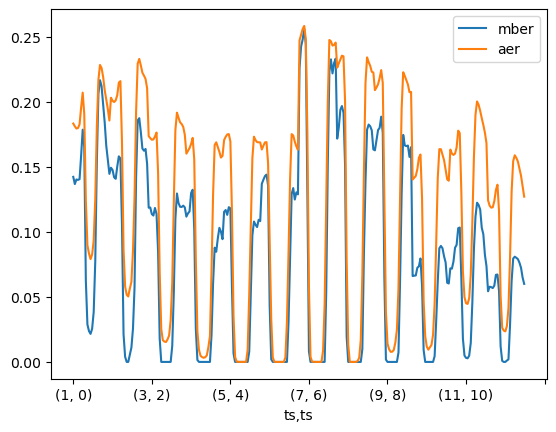

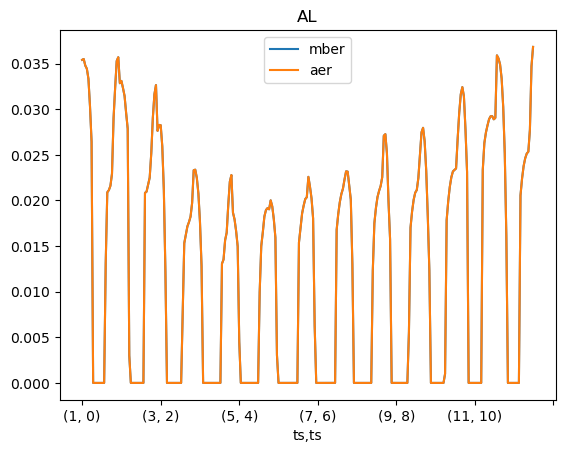

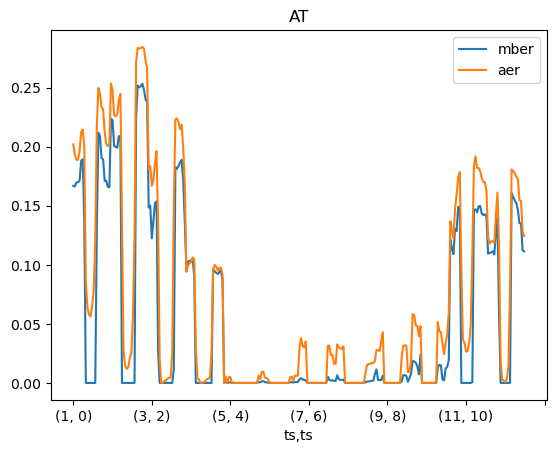

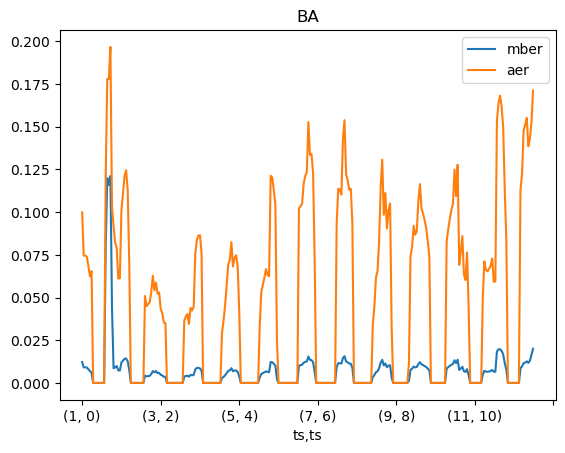

In [6]:
for ctry, df in list(data.items())[:4]:
    df.groupby([df.index.month, df.index.hour]).mean().plot() #GC: x-axis represents a couple (month, hour)
    plt.title(ctry)
    plt.show()

/tmp/ipykernel_250231/3155164426.py:27: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  gen = gen.groupby('carrier',as_index=False).apply(group_carriers)


<Axes: xlabel='year'>

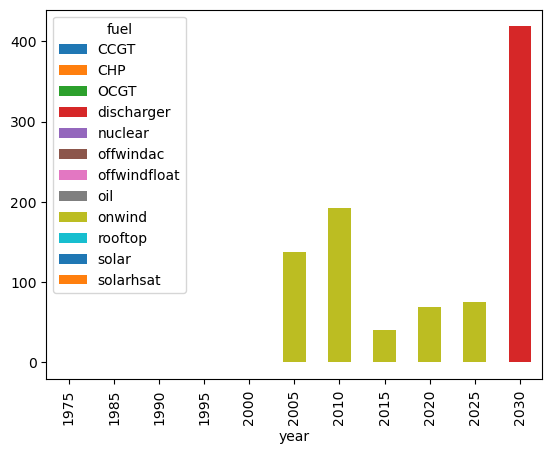

In [7]:
gen, em = get_gen_and_em('ES')

time = gen.index[100]
hour = gen.iloc[100]

hour = pd.DataFrame(hour)
hour.columns = ['gen']
hour['em'] = em.loc[time]
hour.index = hour.index.map(lambda x: x.split(' ')[-1])
hour = hour[hour.index.str.contains('20') | hour.index.str.contains('19')]
hour['year'] = hour.index.map(lambda x: x.split('-')[-1])
hour['fuel'] = hour.index.map(lambda x: ''.join(x.split('-')[:-1]))

aer = hour['em'].sum()/hour['gen'].sum()

h_gen = hour.pivot_table(index='year',columns='fuel',values='gen').fillna(0)
h_em = hour.pivot_table(index='year',columns='fuel',values='em').fillna(0)
h_gen.plot.bar(stacked=True)

# 2 - Calculate MOER

- calculate total emissions in country/bus
- include emissions from neighboring countries using flow tracing
- bin by load deciles
- regress delta E vs delta L and delta RE

In [8]:
buses = n.buses[n.buses['carrier']=='AC']
eb = n.statistics.energy_balance(aggregate_time=False, groupby=['country','carrier','bus_carrier','name']).reset_index()

In [9]:
RE_FUELS = [
       'Reservoir & Dam', 'Offshore Wind (AC)',
       'Offshore Wind (Floating)', 'Onshore Wind', 'Run of River',
       'Solar', 'solar-hsat', 'Offshore Wind (DC)', 'solar rooftop'] #GC: we need to inlcude solar-rooftop (change)


countries = buses['country'].unique()
gbfs = {} # gen by fuel 
demand = {} # demand
ints = {} # interchange
ems = {}
re = {}

for country in countries:
    print(f'Processing {country}')
    gen = eb[(eb['country'] == country) & ((eb['bus_carrier']=='AC') | (eb['bus_carrier']=='low voltage'))] #GC: we need to inlcude solar-rooftop (change)
    gbf = gen.drop(columns=['component','country','bus_carrier','name']).groupby('carrier').sum()
    gbf_dem = gbf[gbf < 0]
    gbf_dem = gbf_dem[(gbf_dem.index != "AC") & (gbf_dem.index != "DC")] #GC: we need to exclude exports, to avoide double counting in the Flow Tracing calculation
    demand[country] = gbf_dem.T.sum(axis=1)

    gbf = gbf.drop(index=['electricity distribution grid'])
    gbfs[country] = gbf
    re[country] = gbf.loc[[f for f in gbf.index if f in RE_FUELS]].T.sum(axis=1)

    DC = gen[gen['carrier']=='DC'].set_index('name').drop(columns=['component','country','carrier','bus_carrier'])
    dc_links = n.links.loc[DC.index]
    dc_links['country0'] = dc_links['bus0'].map(buses['country'])
    dc_links['country1'] = dc_links['bus1'].map(buses['country'])
    dc_links['country'] = dc_links[['country0','country1']].replace(country,'').max(axis=1) # e.g., if the country on which I am iterating is DE and the DC links GB and DK, then dc_links['country'] = 'GB'
    DC_net = DC.groupby(dc_links['country']).sum()

    AC = gen[gen['component']=='Line'].set_index('name').drop(columns=['component','country','carrier','bus_carrier'])
    ac_lines = n.lines.loc[AC.index]
    ac_lines['country0'] = ac_lines['bus0'].map(buses['country'])
    ac_lines['country1'] = ac_lines['bus1'].map(buses['country'])
    ac_lines['country'] = ac_lines[['country0','country1']].replace(country,'').max(axis=1) 
    AC_net = AC.groupby(ac_lines['country']).sum()
    int_net = pd.concat([AC_net,DC_net])
    int_net = int_net.groupby(int_net.index).sum().T
    ints[country] = int_net

    _, em = get_gen_and_em(country)
    ems[country] = em.sum(axis=1)

Processing AL


/tmp/ipykernel_250231/3155164426.py:27: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  gen = gen.groupby('carrier',as_index=False).apply(group_carriers)


Processing AT


/tmp/ipykernel_250231/3155164426.py:27: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  gen = gen.groupby('carrier',as_index=False).apply(group_carriers)


Processing BA


...

/tmp/ipykernel_250231/3155164426.py:27: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  gen = gen.groupby('carrier',as_index=False).apply(group_carriers)


Processing SK


/tmp/ipykernel_250231/3155164426.py:27: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  gen = gen.groupby('carrier',as_index=False).apply(group_carriers)


Processing XK


/tmp/ipykernel_250231/3155164426.py:27: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  gen = gen.groupby('carrier',as_index=False).apply(group_carriers)


### 2.1 - Flow Tracing

Assign emissions from import and export through flow tracing. 

solves the equation: $\bm{F} \vec{E} = \vec{G}$

where $\vec{G}$ is a column vector of emissions from generators in each country, $\vec{E}$ is the consumed emissions rate in each country, which we are solving for, and $\bm{F}$ is the flow matrix accounting for flows between countries.

$\bm{F} = \bm{I} + \mathbb{I} \vec{X} + \mathbb{I} \vec{D}$

where $\bm{I}$ is a matrix of import flows, $\vec{X}$ is a column matrix summing all exports flows from each node, and $\vec{D}$ is a column matrix of consumed demand at each node.

explicitly:

$\bm{F} = \begin{bmatrix}
D_1 + \sum_j X_{1j} & I_{12} & I_{13}\\
I_{21} & D_2 + \sum_j X_{2j} & I_{23}\\
I_{31} & I_{32} & D_3 + \sum_j X_{3j}
\end{bmatrix}$

where $D_i$ is the demand at node $i$, $X_{ij}$ is the exported flow (e.g. when flow is negative) from node $i$ to $j$ and $I_{ij}$ is the imported flow (e.g. when flow is positive)

In [10]:

# total_gen  = {country: gbf.drop(index=['AC','DC'],errors='ignore').T.sum(axis=1) for country, gbf in gbfs.items()}
consumed_em = []
N = 8760
for i in range(N):
    int_matrix = [ints[country].iloc[i] for country in countries]
    int_matrix = pd.concat(int_matrix,axis=1)
    int_matrix.columns = countries
    int_matrix = int_matrix.loc[int_matrix.columns]
    int_matrix = int_matrix.fillna(0).T
    imp_matrix = int_matrix.where(int_matrix>0,0)
    exp = int_matrix.where(int_matrix<0,0).sum(axis=1)

    flow_matrix = imp_matrix
    for country in demand.keys():
        flow_matrix.loc[country,country] = demand[country].iloc[i] + exp[country]


    countries = flow_matrix.index
    gen_em = pd.Series([ems[c].iloc[i] for c in countries],index=countries)

    em_rate = np.linalg.inv(flow_matrix.values) @ gen_em.values
    d = pd.Series([demand[c].iloc[i] for c in countries],index=countries)

    consumed_em.append(em_rate * d)
consumed_em = pd.concat(consumed_em,axis=1).T
consumed_em.index = ems[country].index[:N]


## 2.2 - Regression algorithm
Data is grouped into ten bins by demand decile, then each bin is fit to the regression

$\Delta E = \alpha_i \Delta D + \beta_i \Delta RE + \epsilon_i$

where $E, D$ and $RE$ are the emissions, demand and variable renewable energy generation respectively, and $\Delta$ means the difference between those values at each times step and the previous time step.

Each decile bin for each country is fit to this formula, then the marginal slope $\alpha_i$ is extracted. Each time step is mapped to the matching load decile bin and the corresponding marginal slope, and then the data is grouped by month and hour of day and averaged. This means the MOERs will be the same for each month and hour of day.

In [11]:
import statsmodels.formula.api as smf

moers = {}

for country in countries:
    df = pd.concat([demand[country],consumed_em[country], re[country]],axis=1)
    df.columns = ['demand','em','re']
    df['demand'] = -1*df['demand']
    deltas = df.diff(-1)
    bins = pd.qcut(df['demand'],10)

    slopes = {}
    for bin, _df in deltas.groupby(bins):
        _df = _df.dropna()
        results = smf.ols('em ~ demand + re', data=_df).fit()
        slopes[bin] = results.params['demand']

    h_slope = bins.map(slopes)
    h_slope.index = pd.to_datetime(h_slope.index)
    moers[country] = h_slope.astype(float).groupby([h_slope.index.month,h_slope.index.hour]).transform('mean').clip(lower=0) #GC1: each hours of the same month and hour of the day have the same values [...]
    # [...] e.g., January 1, 01:00 = January 2, 01:00, etc.., which is the avg of all January 01:00
    # GC2: transform negative values in 0, so that the MOER is not negative

/tmp/ipykernel_250231/2862529995.py:13: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  for bin, _df in deltas.groupby(bins):
/tmp/ipykernel_250231/2862529995.py:13: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  for bin, _df in deltas.groupby(bins):
/tmp/ipykernel_250231/2862529995.py:13: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  for bin, _df in deltas.groupby(bins):
/tmp/ipykernel_250231/2862529995.py:13: FutureWarnin

### 2.3 - Save and compare signals

In [16]:
#OUTPUT_DIR = Path() / 'output'
OUTPUT_DIR = os.path.join("..", f"data/emission-signals-model")
os.makedirs(OUTPUT_DIR, exist_ok=True)
for ctry in moers.keys():
    _df = data[ctry]
    _df['moer'] = moers[ctry]
    _df['cmer'] = (_df['mber'] + moers[ctry]) / 2 #GC Includes also cmer as simple average between moer and mber (change)
    _df.to_csv(os.path.join(OUTPUT_DIR, f'{ctry}.csv'))

/tmp/ipykernel_8780/1159837779.py:7: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = cm.get_cmap('viridis')


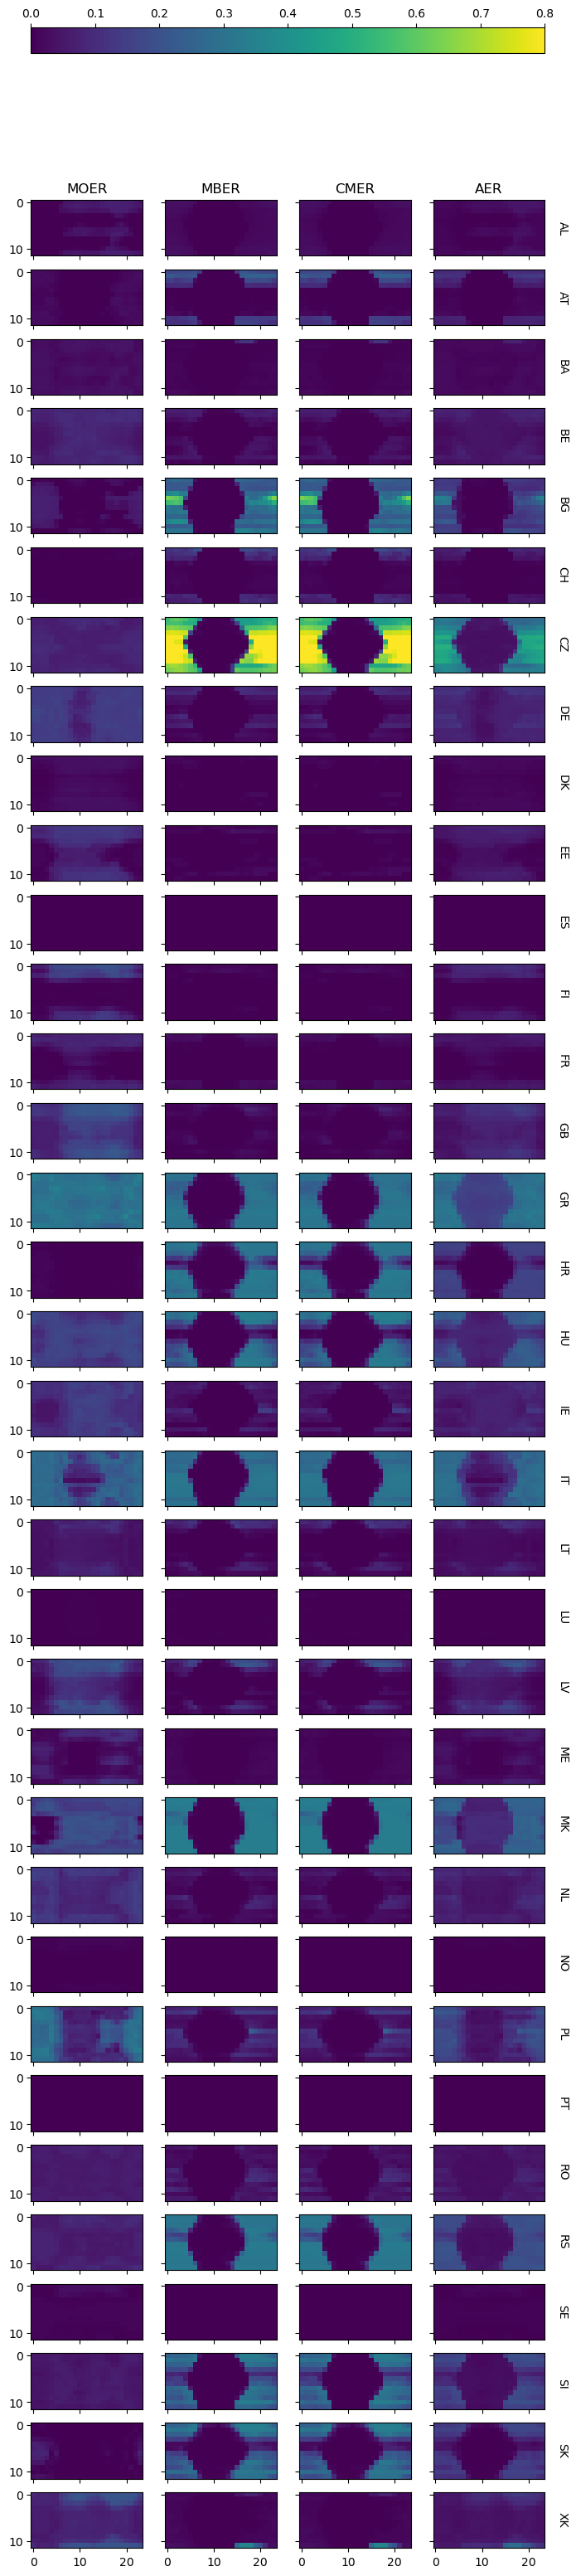

In [ ]:
import matplotlib.cm as cm
from matplotlib.colors import Normalize
from mpl_toolkits.axes_grid1 import make_axes_locatable

f,a = plt.subplots(len(countries),4,figsize=(8,46),sharex=True, sharey=True)

cmap = cm.get_cmap('viridis')
normalizer = Normalize(0, 0.8)
im = cm.ScalarMappable(norm=normalizer)

for i, country in enumerate(countries):
    
    moer = moers[country]
    _df = data[country]

    moer_mh = moer.groupby([moer.index.month, moer.index.hour]).mean().unstack(level=1)
    mber_mh = _df['mber'].groupby([_df.index.month, _df.index.hour]).mean().unstack(level=1)
    aer_mh = _df['aer'].groupby([_df.index.month, _df.index.hour]).mean().unstack(level=1)
    cmer_mh = _df['cmer'].groupby([_df.index.month, _df.index.hour]).mean().unstack(level=1)
    
    a[i][0].imshow(moer_mh, cmap=cmap, norm=normalizer)
    a[i][1].imshow(mber_mh, cmap=cmap, norm=normalizer)
    a[i][2].imshow(mber_mh, cmap=cmap, norm=normalizer)
    im = a[i][3].imshow(cmer_mh, cmap=cmap, norm=normalizer)
    a[i][3].text(26,6.5,country,rotation=-90)

a[0][0].set_title('MOER')
a[0][1].set_title('MBER')
a[0][2].set_title('CMER')
a[0][3].set_title('AER')
# im.colorbar()
f.colorbar(im, ax=a.ravel().tolist(),location='top', pad=0.05)
# plt.tight_layout()
# divider = make_axes_locatable(a.ravel().tolist())
# cax = divider.new_vertical(size = '5%', pad = 0.5)
# f.add_axes(cax)
# f.colorbar(im, cax = cax, orientation = 'horizontal')